In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.compose   import ColumnTransformer
from sklearn.impute    import SimpleImputer
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv('dementia_dataset 400.csv')
df.drop(columns=['Subject ID','MRI ID'], inplace=True)
for col in ['Hand','Group','M/F']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

all_features = [
    'MR Delay','M/F','Hand','Age','EDUC','SES',
    'MMSE','CDR','eTIV','nWBV','ASF'
]

cont_cols = ['MR Delay','Age','EDUC','SES','MMSE','CDR','eTIV','nWBV','ASF']

cat_cols = ['M/F','Hand']


In [6]:
def bernoulli_sample(X):
    col = X[:,0]
    p = np.nanmean(col)
    mask = np.isnan(col)
    col[mask] = np.random.binomial(1, p, size=mask.sum())
    return col.reshape(-1,1)

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='mean'),       cont_cols),
    ('cat_imp', SimpleImputer(strategy='most_frequent'), cat_cols),
])

X_imp = preprocessor.fit_transform(df[cont_cols + cat_cols])
for cat in cat_cols:
    idx = cont_cols.index(cont_cols[-1]) + cat_cols.index(cat) + 1
    col_idx = len(cont_cols) + cat_cols.index(cat)
    X_imp[:, col_idx:col_idx+1] = bernoulli_sample(X_imp[:, col_idx:col_idx+1])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
y = df['Group']
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42
)

#train models
models = {
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_split=10,
        class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=6,
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42),
    'KNN(5)': KNeighborsClassifier(n_neighbors=5)
}

Classification results

Model: Naive Bayes

Training Data:
              precision    recall  f1-score   support

           0       0.80      0.46      0.59        26
           1       0.95      0.97      0.96       102
           2       0.92      0.98      0.95       133

    accuracy                           0.93       261
   macro avg       0.89      0.81      0.83       261
weighted avg       0.92      0.93      0.92       261

Testing Data:
              precision    recall  f1-score   support

           0       0.60      0.27      0.38        11
           1       0.93      0.95      0.94        44
           2       0.90      0.98      0.94        57

    accuracy                           0.90       112
   macro avg       0.81      0.74      0.75       112
weighted avg       0.89      0.90      0.89       112

------------------------------------------------------------
Model: Decision Tree

Training Data:
              precision    recall  f1-score   support

           0

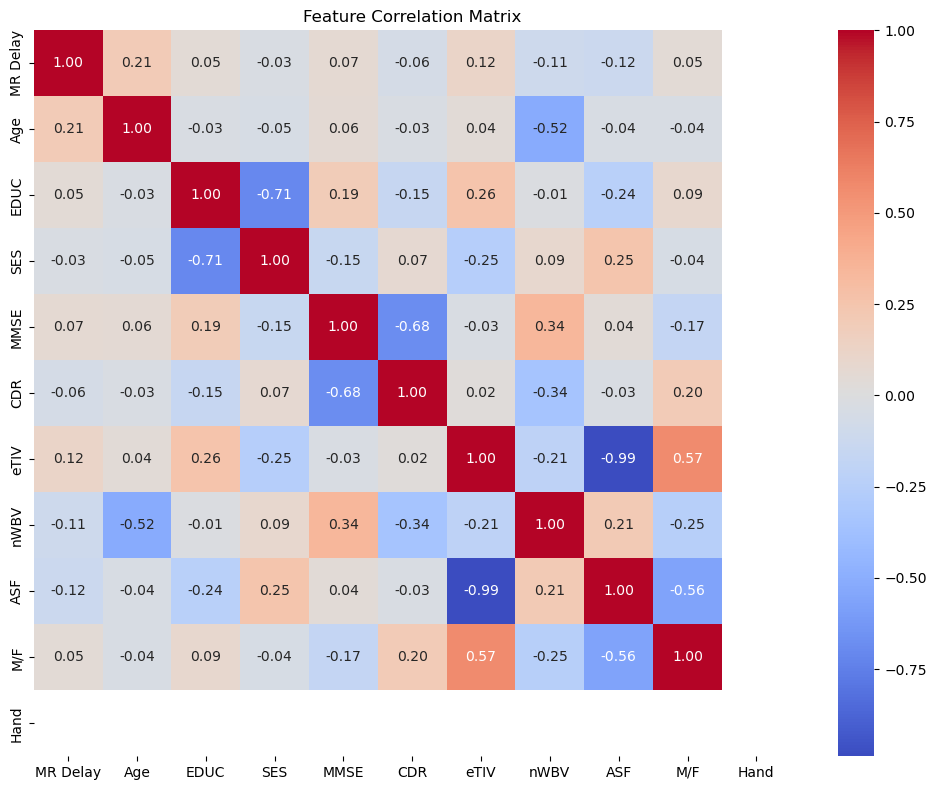

In [7]:
print("Classification results\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Model: {name}\n")
    print("Training Data:")
    print(classification_report(y_train, model.predict(X_train)))
    print("Testing Data:")
    print(classification_report(y_test,  model.predict(X_test)))
    print("-"*60)

#ploting heatmap
eda_df = pd.DataFrame(X_scaled, columns=cont_cols+cat_cols)
plt.figure(figsize=(10,8))
sns.heatmap(eda_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()




=== LR (no penalty) ===


,precision,recall,f1-score,support
0,0.437500,0.636364,0.518519,11.000000
1,0.930233,0.909091,0.919540,44.000000
2,0.943396,0.877193,0.909091,57.000000
accuracy,0.866071,0.866071,0.866071,0.866071
macro avg,0.770376,0.807549,0.782383,112.000000
weighted avg,0.888539,0.866071,0.874836,112.000000



=== LR (L1) ===


,precision,recall,f1-score,support
0,0.437500,0.636364,0.518519,11.000
1,0.952381,0.909091,0.930233,44.000
2,0.944444,0.894737,0.918919,57.000
accuracy,0.875000,0.875000,0.875000,0.875
macro avg,0.778108,0.813397,0.789223,112.000
weighted avg,0.897773,0.875000,0.884039,112.000



=== LR (L2) ===


,precision,recall,f1-score,support
0,0.437500,0.636364,0.518519,11.000000
1,0.930233,0.909091,0.919540,44.000000
2,0.943396,0.877193,0.909091,57.000000
accuracy,0.866071,0.866071,0.866071,0.866071
macro avg,0.770376,0.807549,0.782383,112.000000
weighted avg,0.888539,0.866071,0.874836,112.000000


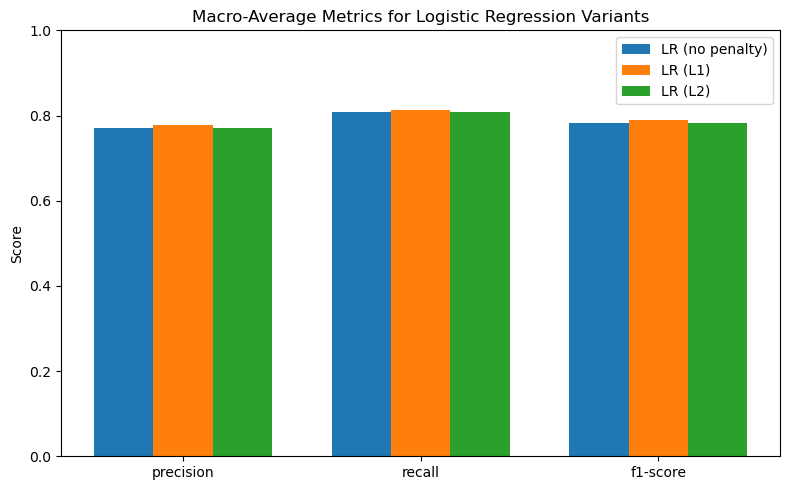

In [8]:
def bernoulli_sample(X):
    col = X[:,0]
    p = np.nanmean(col)
    mask = np.isnan(col)
    col[mask] = np.random.binomial(1, p, size=mask.sum())
    return col.reshape(-1,1)

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='mean'),       cont_cols),
    ('cat_imp', SimpleImputer(strategy='most_frequent'), cat_cols),
])

X_imp = preprocessor.fit_transform(df[cont_cols + cat_cols])
for cat in cat_cols:
    idx = cont_cols.index(cont_cols[-1]) + cat_cols.index(cat) + 1
    col_idx = len(cont_cols) + cat_cols.index(cat)
    X_imp[:, col_idx:col_idx+1] = bernoulli_sample(X_imp[:, col_idx:col_idx+1])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
y = df['Group']
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42)

logistic_variants = {
    'LR (no penalty)': LogisticRegression(
         solver='lbfgs', max_iter=1000, class_weight='balanced'),
    'LR (L1)': LogisticRegression(
        penalty='l1', solver='saga', max_iter=1000, class_weight='balanced'),
    'LR (L2)': LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=1000, class_weight='balanced'),
}

reports = {}
for name, model in logistic_variants.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #metrics dict
    rpt_dict = classification_report(
        y_test, y_pred, output_dict=True, zero_division=0
    )
    reports[name] = pd.DataFrame(rpt_dict).T

for name, df_rpt in reports.items():
    print(f"\n=== {name} ===")
    display(df_rpt[['precision','recall','f1-score','support']])

metrics = ['precision','recall','f1-score']
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(8,5))
for i, (name, df_rpt) in enumerate(reports.items()):
    vals = [df_rpt.loc['macro avg', m] for m in metrics]
    plt.bar(x + i*width, vals, width, label=name)

plt.xticks(x + width, metrics)
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('Macro‐Average Metrics for Logistic Regression Variants')
plt.legend()
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best var_smoothing (α) : 0.01
Best CV macro‑F1      : 0.7516971916971917

Test‐set performance:

              precision    recall  f1-score   support

           0      0.600     0.273     0.375        11
           1      0.955     0.955     0.955        44
           2      0.905     1.000     0.950        57

    accuracy                          0.911       112
   macro avg      0.820     0.742     0.760       112
weighted avg      0.894     0.911     0.895       112



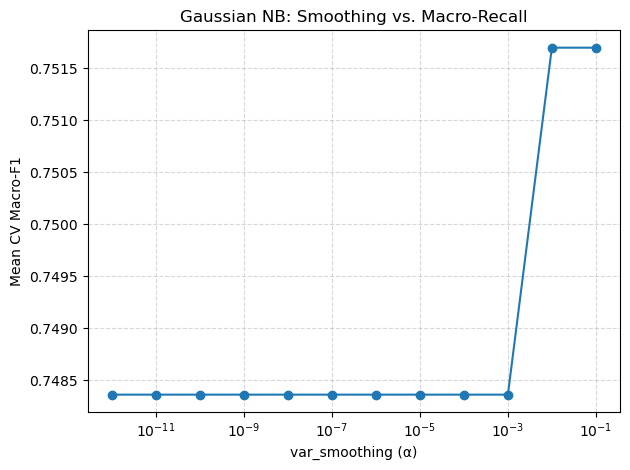

In [9]:
df = pd.read_csv('dementia_dataset 400.csv')
df.drop(columns=['Subject ID','MRI ID'], inplace=True)
for col in ['Hand','Group','M/F']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

cont_cols = ['MR Delay','Age','EDUC','SES','MMSE','CDR','eTIV','nWBV','ASF']
cat_cols  = ['M/F','Hand']

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='mean'),       cont_cols),
    ('cat', SimpleImputer(strategy='most_frequent'), cat_cols),
])
X_imp    = preprocessor.fit_transform(df[cont_cols + cat_cols])
X_scaled = StandardScaler().fit_transform(X_imp)
y        = df['Group']
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42
)

#grid search
param_grid = {
    'var_smoothing': np.logspace(-12, -1, 12)
}
gnb = GaussianNB()
grid = GridSearchCV(
    gnb, param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Best var_smoothing (α) :", grid.best_params_['var_smoothing'])
print("Best CV macro‑F1      :", grid.best_score_)

best_gnb = grid.best_estimator_
y_pred   = best_gnb.predict(X_test)
print("\nTest‐set performance:\n")
print(classification_report(y_test, y_pred, digits=3))

results = pd.DataFrame(grid.cv_results_)
plt.semilogx(
    results['param_var_smoothing'].astype(float),
    results['mean_test_score'],
    marker='o'
)
plt.xlabel('var_smoothing (α)')
plt.ylabel('Mean CV Macro‑F1')
plt.title('Gaussian NB: Smoothing vs. Macro‑Recall')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 210 candidates, totalling 1050 fits
Best DecisionTree params: {'class_weight': 'balanced', 'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 2}
Best CV macro‑F1: 0.7041925386311352

Test‑set classification report:

              precision    recall  f1-score   support

           0      0.294     0.455     0.357        11
           1      0.974     0.864     0.916        44
           2      0.911     0.895     0.903        57

    accuracy                          0.839       112
   macro avg      0.726     0.738     0.725       112
weighted avg      0.875     0.839     0.854       112



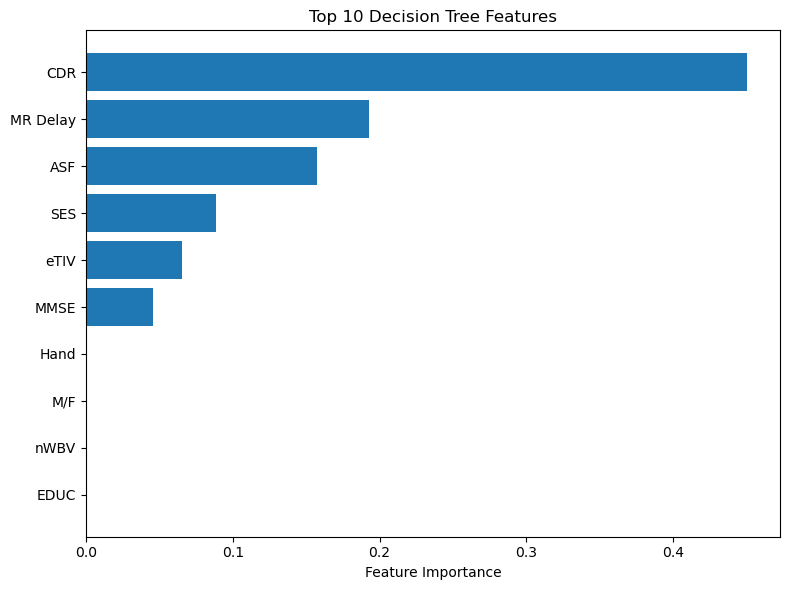

Top 5 risk factors (Decision Tree):
  CDR        : 0.4501
  MR Delay   : 0.1930
  ASF        : 0.1571
  SES        : 0.0889
  eTIV       : 0.0655
Decision Tree Train Accuracy: 0.885, Error: 0.115
Decision Tree Test  Accuracy: 0.839, Error: 0.161


In [10]:
df = pd.read_csv('dementia_dataset 400.csv')
df.drop(columns=['Subject ID','MRI ID'], inplace=True)
for col in ['Hand','Group','M/F']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

cont_cols = ['MR Delay','Age','EDUC','SES','MMSE','CDR','eTIV','nWBV','ASF']
cat_cols  = ['M/F','Hand']

# Impute
pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='mean'), cont_cols),
    ('cat', SimpleImputer(strategy='most_frequent'), cat_cols),
])
X_imp = pre.fit_transform(df[cont_cols + cat_cols])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, df['Group'], test_size=0.3, stratify=df['Group'], random_state=42
)

param_grid = {
    'max_depth': [4,5, 6,7, 8, 10, None],
    'min_samples_split': [2,3,4, 5, 10],
    'min_samples_leaf': [3,4, 5],
    'class_weight': [None, 'balanced']
}
dt = DecisionTreeClassifier(random_state=42, ccp_alpha= 0.0153)
grid_dt = GridSearchCV(
    dt, param_grid,
    cv=5, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_dt.fit(X_train, y_train)

print("Best DecisionTree params:", grid_dt.best_params_)
print("Best CV macro‑F1:", grid_dt.best_score_)

#eval on test set
best_dt = grid_dt.best_estimator_
y_pred = best_dt.predict(X_test)
print("\nTest‑set classification report:\n")
print(classification_report(y_test, y_pred, digits=3))

feat_names = cont_cols + cat_cols
importances = best_dt.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.barh(
    [feat_names[i] for i in indices[:10]][::-1],
    importances[indices][:10][::-1]
)
plt.xlabel("Feature Importance")
plt.title("Top 10 Decision Tree Features")
plt.tight_layout()
plt.show()


feature_names = cont_cols + cat_cols  
importances   = best_dt.feature_importances_

#build series
feat_imp = pd.Series(importances, index=feature_names)
top5     = feat_imp.sort_values(ascending=False).head(5)

print("Top 5 risk factors (Decision Tree):")
for feat, imp in top5.items():
    print(f"  {feat:<10} : {imp:.4f}")


y_train_pred = best_dt.predict(X_train)
y_test_pred  = best_dt.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

train_err = 1 - train_acc
test_err  = 1 - test_acc

print(f"Decision Tree Train Accuracy: {train_acc:.3f}, Error: {train_err:.3f}")
print(f"Decision Tree Test  Accuracy: {test_acc:.3f}, Error: {test_err:.3f}")

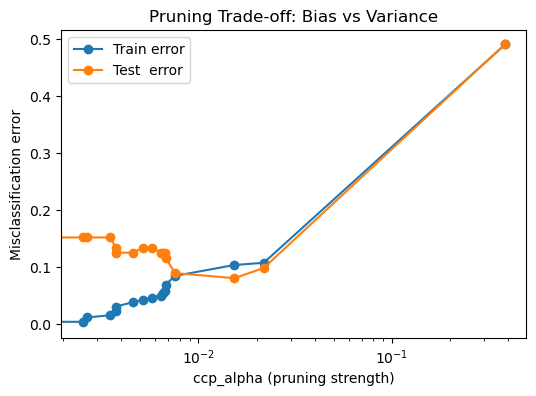

Optimal ccp_alpha: 0.0153, test error: 0.080
Top 10 lines of the tree:

|--- CDR <= -0.11
|   |--- class: 2
|--- CDR >  -0.11
|   |--- MR Delay <= 1.13
|   |   |--- class: 1
|   |--- MR Delay >  1.13
|   |   |--- class: 0



In [11]:
#unpruned tree fitting for ccp path
dt0 = DecisionTreeClassifier(random_state=42)
path = dt0.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

train_err, test_err = [], []
for a in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=a)
    clf.fit(X_train, y_train)
    train_err.append(1 - accuracy_score(y_train, clf.predict(X_train)))
    test_err.append(1 - accuracy_score(y_test,  clf.predict(X_test)))

plt.figure(figsize=(6,4))
plt.plot(ccp_alphas, train_err,  marker='o', label='Train error')
plt.plot(ccp_alphas, test_err,   marker='o', label='Test  error')
plt.xscale('log')
plt.xlabel('ccp_alpha (pruning strength)')
plt.ylabel('Misclassification error')
plt.legend()
plt.title('Pruning Trade‑off: Bias vs Variance')
plt.show()


best_idx  = np.argmin(test_err)
best_alpha = ccp_alphas[best_idx]
print(f"Optimal ccp_alpha: {best_alpha:.4f}, test error: {test_err[best_idx]:.3f}")

pruned_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_dt.fit(X_train, y_train)

from sklearn.tree import export_text
full_rules = export_text(pruned_dt, feature_names=feature_names)

lines = full_rules.split('\n')
snippet = "\n".join(lines[:10])

print("Top 10 lines of the tree:\n")
print(snippet)


